In [1]:
##! python -m pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
print("Blank TotalCharges:", (df["TotalCharges"] == " ").sum())

Blank TotalCharges: 11


In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")


In [9]:
df["TotalCharges"]

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [10]:
df["TotalCharges"]= df["TotalCharges"].fillna(df["TotalCharges"].median())

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
df.drop('customerID', axis=1, inplace=True)

In [13]:
bins = [0, 12, 24, 48, 60, 72]
labels = ['0-12', '12-24', '24-48', '48-60', '60-72']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)


In [14]:
df['tenure_group']

0        0-12
1       24-48
2        0-12
3       24-48
4        0-12
        ...  
7038    24-48
7039      NaN
7040     0-12
7041     0-12
7042    60-72
Name: tenure_group, Length: 7043, dtype: category
Categories (5, str): ['0-12' < '12-24' < '24-48' < '48-60' < '60-72']

In [15]:
# Avg Monthly Spend
df["AvgMonthlySpend"] = df["TotalCharges"] / df["tenure"]
df["AvgMonthlySpend"].replace([np.inf, -np.inf], 0, inplace=True)
df["AvgMonthlySpend"].fillna(0, inplace=True)

C:\Users\ANKIT AGRAWAL\AppData\Local\Temp\ipykernel_9888\948300048.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["AvgMonthlySpend"].replace([np.inf, -np.inf], 0, inplace=True)
C:\Users\ANKIT AGRAWAL\AppData\Local\Temp\ipykernel_9888\948300048.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Seri

0        29.850000
1        55.573529
2        54.075000
3        40.905556
4        75.825000
           ...    
7038     82.937500
7039    102.262500
7040     31.495455
7041     76.650000
7042    103.704545
Name: AvgMonthlySpend, Length: 7043, dtype: float64

In [16]:
# Convert Yes/No to 1/0
binary_cols = ["Partner","Dependents","PhoneService","PaperlessBilling","Churn"]
for col in binary_cols:
    df[col] = df[col].map({"Yes":1, "No":0})

In [17]:
 df[col]

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [18]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [19]:
df_encoded

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_12-24,tenure_group_24-48,tenure_group_48-60,tenure_group_60-72
0,0,1,0,1,0,1,29.85,29.85,0,29.850000,...,False,False,False,False,True,False,False,False,False,False
1,0,0,0,34,1,0,56.95,1889.50,0,55.573529,...,False,True,False,False,False,True,False,True,False,False
2,0,0,0,2,1,1,53.85,108.15,1,54.075000,...,False,False,False,False,False,True,False,False,False,False
3,0,0,0,45,0,0,42.30,1840.75,0,40.905556,...,False,True,False,False,False,False,False,True,False,False
4,0,0,0,2,1,1,70.70,151.65,1,75.825000,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,1,1,84.80,1990.50,0,82.937500,...,True,True,False,False,False,True,False,True,False,False
7039,0,1,1,72,1,1,103.20,7362.90,0,102.262500,...,True,True,False,True,False,False,False,False,False,False
7040,0,1,1,11,0,1,29.60,346.45,0,31.495455,...,False,False,False,False,True,False,False,False,False,False
7041,1,1,0,4,1,1,74.40,306.60,1,76.650000,...,False,False,False,False,False,True,False,False,False,False


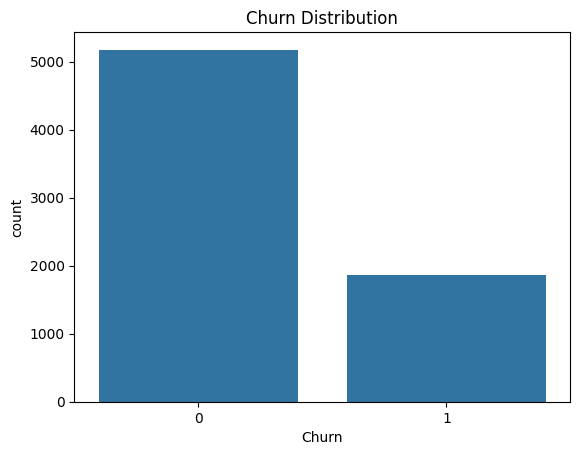

In [20]:
# Churn Countplot
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

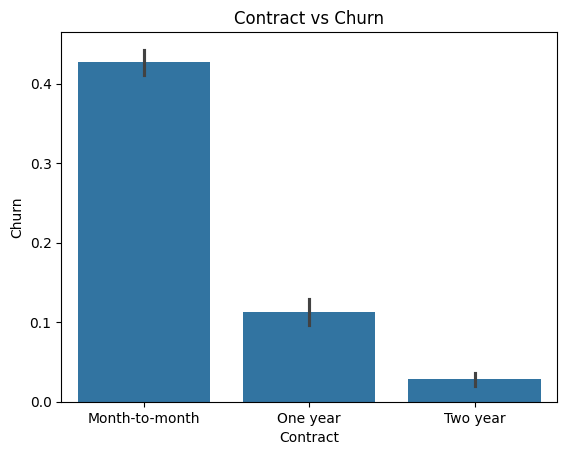

In [21]:
# Contract vs Churn
sns.barplot(x="Contract", y="Churn", data=df)
plt.title("Contract vs Churn")
plt.show()

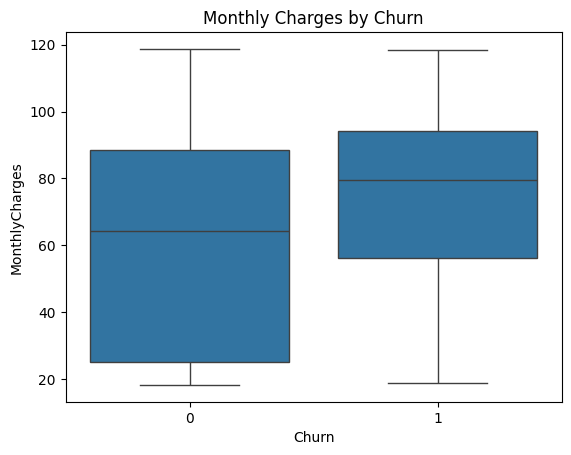

In [22]:
# Monthly Charges vs Churn
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn")
plt.show()

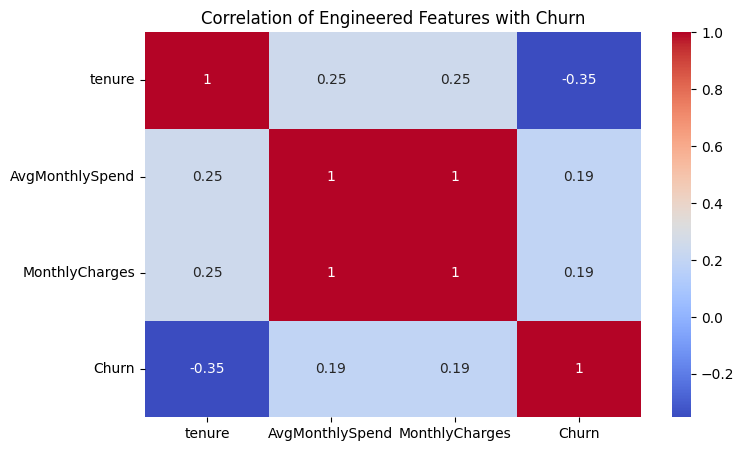

In [23]:
# Correlation Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(
    df_encoded[["tenure", "AvgMonthlySpend", "MonthlyCharges", "Churn"]]
    .corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation of Engineered Features with Churn")
plt.show()


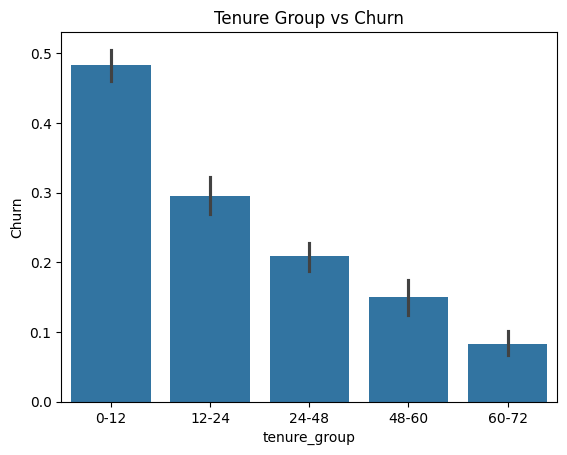

In [24]:
#Tenure Group vs Churn
sns.barplot(x="tenure_group", y="Churn", data=df)
plt.title("Tenure Group vs Churn")
plt.show()


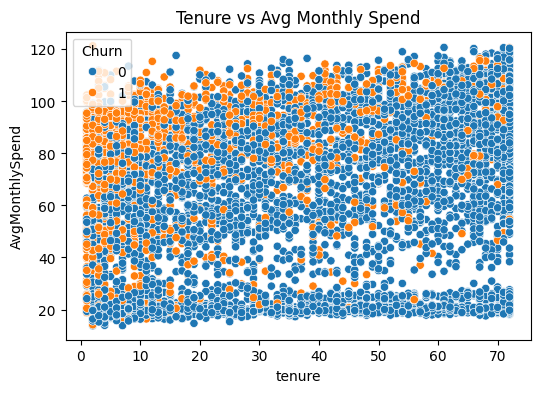

In [25]:
# Tenure vs Avg Monthly Spend
plt.figure(figsize=(6,4))
sns.scatterplot(x="tenure", y="AvgMonthlySpend", hue="Churn", data=df)
plt.title("Tenure vs Avg Monthly Spend")
plt.show()


### ML Feature Importance Plots (Customer Churn)

In [26]:
#Prepare Data for ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [27]:
df_encoded.replace([np.inf, -np.inf], np.nan, inplace=True)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_12-24,tenure_group_24-48,tenure_group_48-60,tenure_group_60-72
0,0,1,0,1,0,1,29.85,29.85,0,29.850000,...,False,False,False,False,True,False,False,False,False,False
1,0,0,0,34,1,0,56.95,1889.50,0,55.573529,...,False,True,False,False,False,True,False,True,False,False
2,0,0,0,2,1,1,53.85,108.15,1,54.075000,...,False,False,False,False,False,True,False,False,False,False
3,0,0,0,45,0,0,42.30,1840.75,0,40.905556,...,False,True,False,False,False,False,False,True,False,False
4,0,0,0,2,1,1,70.70,151.65,1,75.825000,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,1,1,84.80,1990.50,0,82.937500,...,True,True,False,False,False,True,False,True,False,False
7039,0,1,1,72,1,1,103.20,7362.90,0,102.262500,...,True,True,False,True,False,False,False,False,False,False
7040,0,1,1,11,0,1,29.60,346.45,0,31.495455,...,False,False,False,False,True,False,False,False,False,False
7041,1,1,0,4,1,1,74.40,306.60,1,76.650000,...,False,False,False,False,False,True,False,False,False,False


In [28]:
df_encoded = df_encoded.fillna(df_encoded.median())


In [29]:
print(np.isinf(df_encoded).sum().sum())  # should be 0
print(df_encoded.isna().sum().sum())     # should be 0


0
0


In [30]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [32]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [34]:
model_lr = LogisticRegression(
    solver="liblinear",
    max_iter=1000
)

model_lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

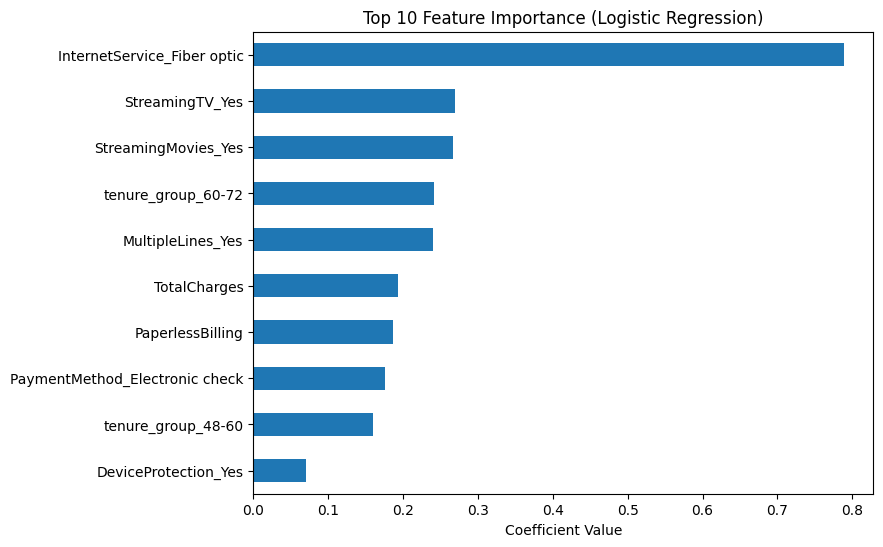

In [35]:
importance = pd.Series(
    model_lr.coef_[0],
    index=X_train.columns
).sort_values()

plt.figure(figsize=(8,6))
importance.tail(10).plot(kind="barh")
plt.title("Top 10 Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.show()


In [36]:
#RANdom Forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)
y_pred = rf_model.predict(X_test_scaled)


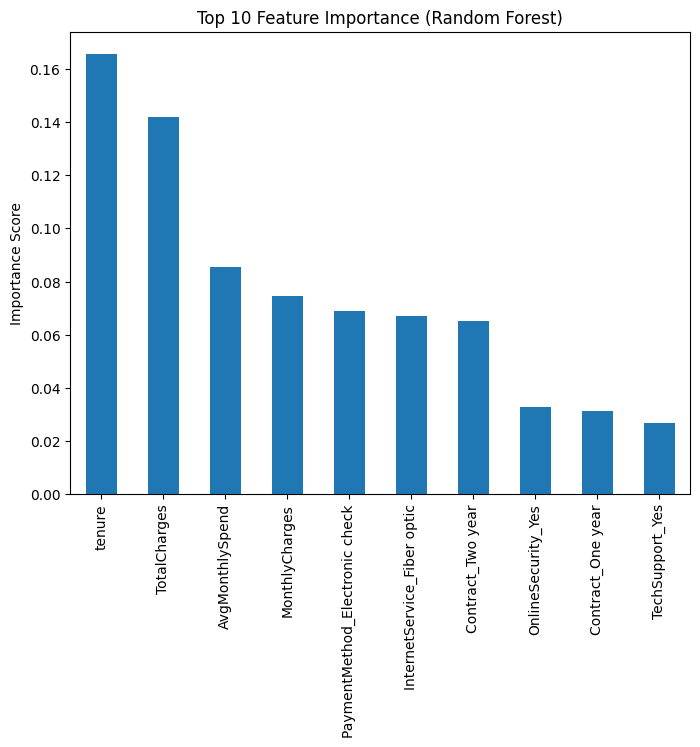

In [37]:
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
rf_importance.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importance (Random Forest)")
plt.ylabel("Importance Score")
plt.show()


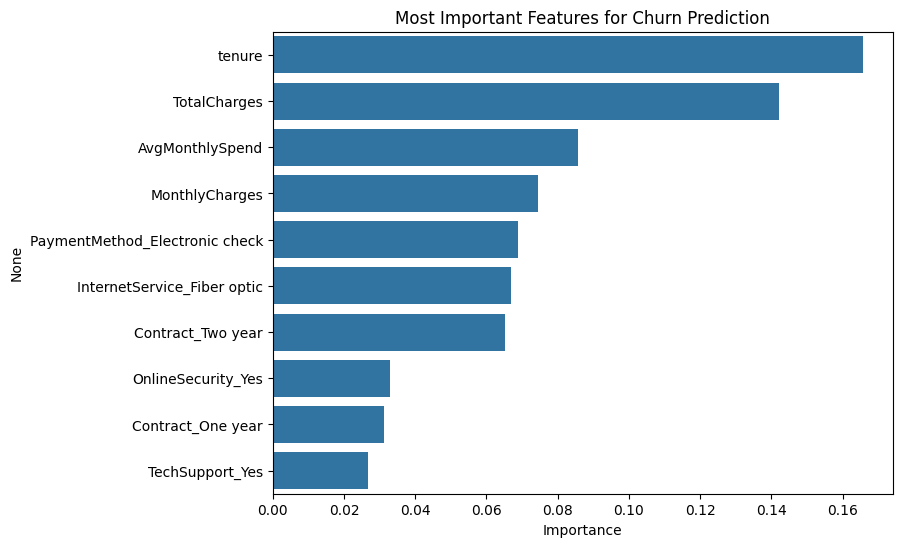

In [38]:
top_features = rf_importance.head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Most Important Features for Churn Prediction")
plt.xlabel("Importance")
plt.show()


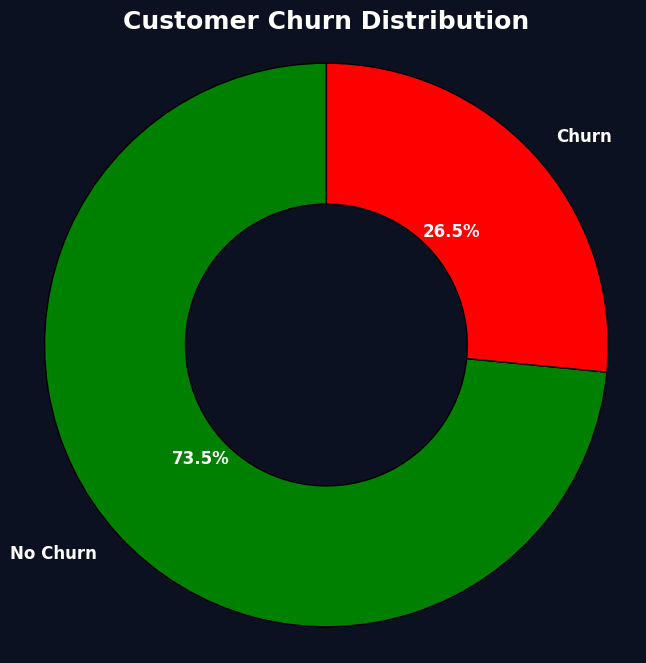

In [39]:
import matplotlib.pyplot as plt

# Churn Counts
churn_counts = df["Churn"].value_counts()

# Labels
labels = ["No Churn", "Churn"]

# Colors
colors = ["green", "red"]

# Create Figure
plt.figure(figsize=(8, 8), facecolor="#0B1120")

# Donut Chart
wedges, texts, autotexts = plt.pie(
    churn_counts,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={
        "width": 0.5,      # Creates donut hole
        "edgecolor": "black"
    },
    textprops={
        "color": "white",
        "fontsize": 12,
        "weight": "bold"
    }
)

# Title
plt.title(
    "Customer Churn Distribution",
    color="white",
    fontsize=18,
    weight="bold"
)

# Dark Background
plt.gca().set_facecolor("#0B1120")

# Equal Circle
plt.axis("equal")

# Show Plot
plt.show()

In [40]:
y_pred = model_lr.predict(X_test_scaled)



In [41]:
y_pred_prob = model_lr.predict_proba(X_test_scaled)[:, 1]

In [42]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[928 107]
 [179 195]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



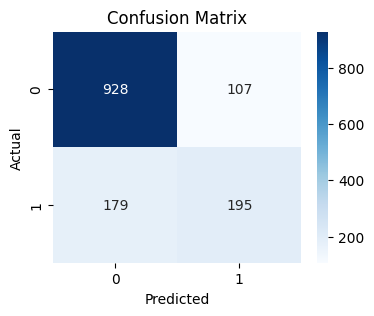

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


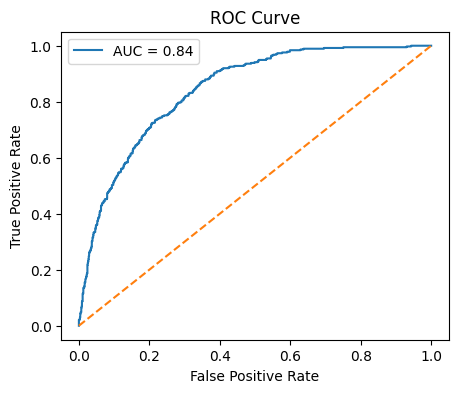

In [44]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [45]:
sample = X_test.iloc[0:1]
sample_scaled = scaler.transform(sample)
prediction = model_lr.predict(sample_scaled)

print("Churn Prediction:", "Yes" if prediction[0]==1 else "No")


Churn Prediction: No


In [46]:
import joblib

In [47]:
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_train.columns.tolist(), "feature_names.pkl")

print("✅ Random Forest model saved successfully")


✅ Random Forest model saved successfully


In [48]:
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,AvgMonthlySpend
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,...,No,No,Month-to-month,1,Electronic check,29.85,29.85,0,0-12,29.850000
1,Male,0,0,0,34,1,No,DSL,Yes,No,...,No,No,One year,0,Mailed check,56.95,1889.50,0,24-48,55.573529
2,Male,0,0,0,2,1,No,DSL,Yes,Yes,...,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,0-12,54.075000
3,Male,0,0,0,45,0,No phone service,DSL,Yes,No,...,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0,24-48,40.905556
4,Female,0,0,0,2,1,No,Fiber optic,No,No,...,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,0-12,75.825000
